100%|██████████| 5/5 [00:07<00:00,  1.48s/it]


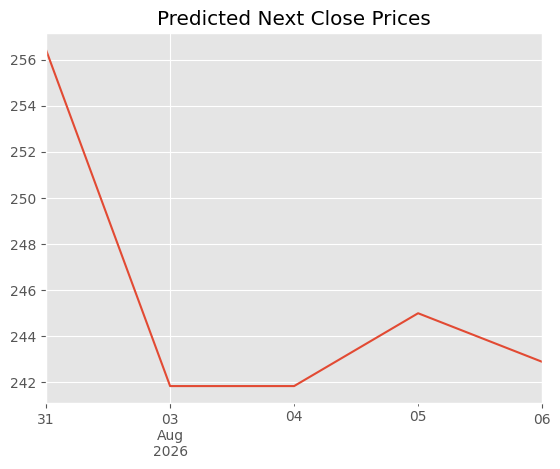

In [33]:
# @title Forecasting stock price for the next four days { run: "auto", display-mode: "form" }
import datetime
import itertools
import logging
import warnings
from docopt import docopt
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import yfinance as yf

Company = "RELIANCE.NS"  # @param{type:"string"}

msft = yf.Ticker(Company)
data = msft.history(period="max")
data.index = data.index.tz_localize(None)
# Supress warnings in hmmlearn
warnings.filterwarnings("ignore")
plt.style.use("ggplot")


def nxtpre(phase):
    global data
    now = datetime.datetime.now()
    weekday = now.weekday()

    # Define day offsets based on weekday and phase
    offsets = {
        0: [1, 2, 3, 4],
        1: [1, 2, 3, 6],
        2: [1, 2, 5, 6],
        3: [1, 4, 5, 6],
        4: [3, 4, 5, 6],
        5: [2, 3, 4, 5],
        6: [1, 2, 3, 4],
    }

    days_to_add = offsets[weekday][phase]
    new_index = pd.DatetimeIndex(
        [(now + datetime.timedelta(days=days_to_add)).strftime("%Y-%m-%d")]
    )
    new_row = pd.DataFrame(index=new_index)

    # Replaced data.append() with pd.concat()
    data = pd.concat([data, new_row])


class StockPredictor(object):

    def __init__(
        self,
        test_size=None,
        n_hidden_states=5,
        n_latency_days=10,
        n_steps_frac_change=50,
        n_steps_frac_high=10,
        n_steps_frac_low=10,
    ):
        self.n_latency_days = n_latency_days
        self.hmm = GaussianHMM(n_components=n_hidden_states)

        if test_size is None:
            test_size = 5 / data.shape[0]

        self._split_train_test_data(test_size)
        self._compute_all_possible_outcomes(
            n_steps_frac_change, n_steps_frac_high, n_steps_frac_low
        )

    def _split_train_test_data(self, test_size):
        # Calculate features using Pandas vectorized operations
        data["ema1"] = data["Close"].shift(1)
        data["ema7"] = data["Close"].rolling(window=7).mean().shift(1)
        data["ema10"] = data["Close"].rolling(window=10).mean().shift(1)
        data["EmA20"] = data["Close"].rolling(window=20).mean().shift(1)

        _train_data, test_data = train_test_split(
            data.dropna(), test_size=test_size, shuffle=False
        )

        self._train_data = _train_data
        self._test_data = test_data

    @staticmethod
    def _extract_features(df):
        close_price = np.array(df["Close"])
        ema = np.array(df["EmA20"])
        ema7 = np.array(df["ema7"])
        ema10 = np.array(df["ema10"])

        frac_change = (ema - close_price) / ema
        frac_high = (ema - ema7) / ema7
        frac_low = (ema - ema10) / ema10

        return np.column_stack((frac_change, frac_high, frac_low))

    def fit(self):
        feature_vector = StockPredictor._extract_features(self._train_data)
        self.hmm.fit(feature_vector)

    def _compute_all_possible_outcomes(
        self, n_steps_frac_change, n_steps_frac_high, n_steps_frac_low
    ):
        frac_change_range = np.linspace(-0.1, 0.1, n_steps_frac_change)
        frac_high_range = np.linspace(0, 0.1, n_steps_frac_high)
        frac_low_range = np.linspace(0, 0.1, n_steps_frac_low)

        self._possible_outcomes = np.array(
            list(
                itertools.product(
                    frac_change_range, frac_high_range, frac_low_range
                )
            )
        )

    def _get_most_probable_outcome(self, day_index):
        previous_data_start_index = max(0, day_index - self.n_latency_days)
        previous_data_end_index = max(0, day_index - 1)
        previous_data = self._test_data.iloc[
            previous_data_end_index:previous_data_start_index
        ]
        previous_data_features = StockPredictor._extract_features(
            previous_data
        )

        outcome_score = []
        for possible_outcome in self._possible_outcomes:
            total_data = np.row_stack(
                (previous_data_features, possible_outcome)
            )
            outcome_score.append(self.hmm.score(total_data))

        most_probable_outcome = self._possible_outcomes[
            np.argmax(outcome_score)
        ]
        return most_probable_outcome

    def predict_close_price(self, day_index):
        open_price = self._test_data.iloc[day_index]["ema1"]
        predicted_frac_change, _, _ = self._get_most_probable_outcome(
            day_index
        )
        return open_price * (1 + predicted_frac_change)

    def predict_close_prices_for_days(self, days, with_plot=False):
        predicted_close_prices = []
        for day_index in tqdm(range(days)):
            predicted_close_prices.append(
                self.predict_close_price(day_index)
            )

        data.iloc[-1, data.columns.get_loc("Close")] = predicted_close_prices[
            -1
        ]
        return predicted_close_prices


# Run prediction phases
for phase in range(0, 4):
    nxtpre(phase)
    stock_predictor = StockPredictor()
    stock_predictor.fit()
    stock_predictor.predict_close_prices_for_days(5, with_plot=True)

data["Close"][-5:].plot(title="Predicted Next Close Prices")
plt.show()

2026-08-01 22:17:09,628 __main__     INFO     >>> Extracting Features
INFO:__main__:>>> Extracting Features
2026-08-01 22:17:09,633 __main__     INFO     Features extraction Completed <<<
INFO:__main__:Features extraction Completed <<<
100%|██████████| 50/50 [01:13<00:00,  1.47s/it]


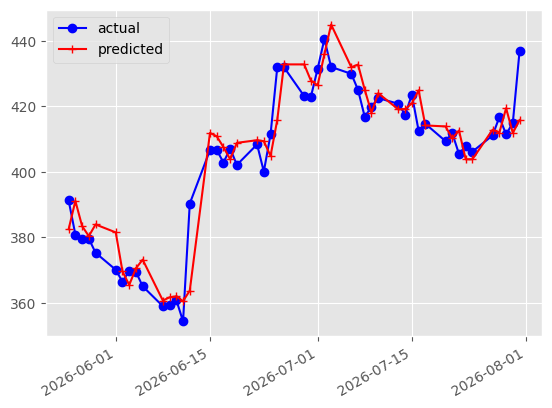

[np.float64(382.4703264693562),
 np.float64(391.09078943802473),
 np.float64(383.41165077619576),
 np.float64(380.3399918536751),
 np.float64(383.9070761258698),
 np.float64(381.47945896443184),
 np.float64(369.58921044816816),
 np.float64(365.4275922021314),
 np.float64(370.53052294046734),
 np.float64(373.15629522753363),
 np.float64(360.67149246978465),
 np.float64(361.662339778338),
 np.float64(361.95959140449037),
 np.float64(360.47331515659306),
 np.float64(363.74081632653065),
 np.float64(411.8387755102041),
 np.float64(410.8367346938776),
 np.float64(407.53001223194354),
 np.float64(403.82244897959185),
 np.float64(408.8326530612245),
 np.float64(409.63427348234217),
 np.float64(409.33367346938775),
 np.float64(404.8244897959184),
 np.float64(415.84693877551024),
 np.float64(432.7814224554568),
 np.float64(432.7814224554568),
 np.float64(427.8213387625558),
 np.float64(426.41845715581155),
 np.float64(435.88775510204084),
 np.float64(444.95621225785237),
 np.float64(431.9296816

In [25]:
#@title forecast stock price for testing { run: "auto", display-mode: "form" }
company = 'TMCV.NS' #@param{type:"string"}
days =  50#@param{type:"integer"}

import warnings
import logging
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from docopt import docopt
import yfinance as yf



# args = docopt(doc=__doc__, argv=None, help=True,
#               version=None, options_first=False)

# Supress warning in hmmlearn
warnings.filterwarnings("ignore")
# Change plot style to ggplot (for better and more aesthetic visualisation)
plt.style.use('ggplot')
# class data_fetch(object):
#     msft = yf.Ticker("RELIANCE.NS")
#     data  = (msft.history(period="max"))

class StockPredictor(object):
#     print(1)
    global data
    msft = yf.Ticker(company)
    data  = (msft.history(period="max"))

    def __init__(self,test_size=days/data.shape[0],
                 n_hidden_states=4, n_latency_days=10,
                 n_steps_frac_change=50, n_steps_frac_high=10,
                 n_steps_frac_low=10):
        self._init_logger()



#         self.test_size=

#         self.company = company
#         global data
        self.n_latency_days = n_latency_days

        self.hmm = GaussianHMM(n_components=n_hidden_states)

        self._split_train_test_data(test_size)

        self._compute_all_possible_outcomes(
            n_steps_frac_change, n_steps_frac_high, n_steps_frac_low)

    def _init_logger(self):
        self._logger = logging.getLogger(__name__)
        handler = logging.StreamHandler()
        formatter = logging.Formatter(
            '%(asctime)s %(name)-12s %(levelname)-8s %(message)s')
        handler.setFormatter(formatter)
        self._logger.addHandler(handler)
        self._logger.setLevel(logging.DEBUG)

    def _split_train_test_data(self, test_size):
#         msft = yf.Ticker("RELIANCE.NS")
#         data  = (msft.history(period="max"))
#         data = pd.read_csv(
#             'data/company_data/{company}.csv'.format(company=self.company))
        _train_data, test_data = train_test_split(
            data, test_size=test_size, shuffle=False)

        self._train_data = _train_data
        self._test_data = test_data

    @staticmethod
    def _extract_features(data):
        open_price = np.array(data['Open'])
        close_price = np.array(data['Close'])
        high_price = np.array(data['High'])
        low_price = np.array(data['Low'])

        # Compute the fraction change in close, high and low prices
        # which would be used a feature
        frac_change = (close_price - open_price) / open_price
        frac_high = (high_price - open_price) / open_price
        frac_low = (open_price - low_price) / open_price

        return np.column_stack((frac_change, frac_high, frac_low))

    def fit(self):
        self._logger.info('>>> Extracting Features')
        feature_vector = StockPredictor._extract_features(self._train_data)
        self._logger.info('Features extraction Completed <<<')

        self.hmm.fit(feature_vector)

    def _compute_all_possible_outcomes(self, n_steps_frac_change,
                                       n_steps_frac_high, n_steps_frac_low):
        frac_change_range = np.linspace(-0.1, 0.1, n_steps_frac_change)
        frac_high_range = np.linspace(0, 0.1, n_steps_frac_high)
        frac_low_range = np.linspace(0, 0.1, n_steps_frac_low)

        self._possible_outcomes = np.array(list(itertools.product(
            frac_change_range, frac_high_range, frac_low_range)))

    def _get_most_probable_outcome(self, day_index):
        previous_data_start_index = max(0, day_index - self.n_latency_days)
        previous_data_end_index = max(0, day_index - 1)
        previous_data = self._test_data.iloc[previous_data_end_index: previous_data_start_index]
        previous_data_features = StockPredictor._extract_features(
            previous_data)

        outcome_score = []
        for possible_outcome in self._possible_outcomes:
            total_data = np.row_stack(
                (previous_data_features, possible_outcome))
            outcome_score.append(self.hmm.score(total_data))
        most_probable_outcome = self._possible_outcomes[np.argmax(
            outcome_score)]

        return most_probable_outcome

    def predict_close_price(self, day_index):
        open_price = self._test_data.iloc[day_index]['Open']
        predicted_frac_change, _, _ = self._get_most_probable_outcome(
            day_index)
        return open_price * (1 + predicted_frac_change)

    def predict_close_prices_for_days(self, days, with_plot=False):
        predicted_close_prices = []
        for day_index in tqdm(range(days)):
            predicted_close_prices.append(self.predict_close_price(day_index))

        if with_plot:
            test_data = self._test_data[0: days]
            days = np.array(test_data.index)
            actual_close_prices = test_data['Close']

            fig = plt.figure()

            axes = fig.add_subplot(111)
            axes.plot(days, actual_close_prices, 'bo-', label="actual")
            axes.plot(days, predicted_close_prices, 'r+-', label="predicted")
#             axes.set_title('{company}'.format(company=self.company))

            fig.autofmt_xdate()

            plt.legend()
            plt.show()

        return predicted_close_prices
# global data
# msft = yf.Ticker("RELIANCE.NS")
# data  = (msft.history(period="max"))
# print(1)
# da1 = data_fetch()
stock_predictor = StockPredictor()
stock_predictor.fit()
stock_predictor.predict_close_prices_for_days(days, with_plot=True)


In [7]:
pip install yfinance

In [8]:
pip install hmmlearn

In [9]:
pip install docopt